In [1]:
import pandas as pd

In [5]:
df = pd.read_csv('Mall_Customers.csv')
df = df.drop('CustomerID', axis=1)
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [13]:
print(df.isnull().sum())
print(df.dtypes)

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [16]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

df['Gender'] = OrdinalEncoder().fit_transform(df[['Gender']])
X_scaled = StandardScaler().fit_transform(df)

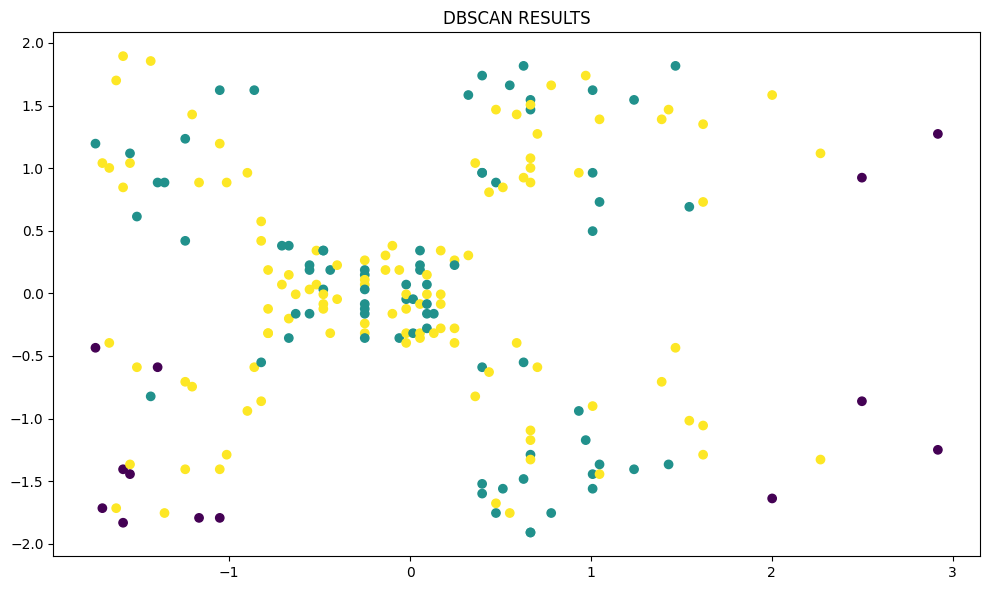

 1    110
 0     77
-1     13
Name: count, dtype: int64


In [29]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt 

dbscan = DBSCAN(eps=1, min_samples=5)
lables_dbscan = dbscan.fit_predict(X_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 2], X_scaled[:, 3], c=lables_dbscan)
plt.title('DBSCAN RESULTS')
plt.tight_layout()
plt.show()
print(pd.Series(lables_dbscan).value_counts())

In [44]:
df['cluster'] = lables_dbscan
outliers = df[df['cluster'] == -1]
print(outliers.describe())

          Gender        Age  Annual Income (k$)  Spending Score (1-100)  \
count  13.000000  13.000000           13.000000               13.000000   
mean    0.846154  40.538462           62.692308               25.307692   
std     0.375534  15.935366           54.108509               26.455575   
min     0.000000  19.000000           15.000000                3.000000   
25%     1.000000  32.000000           19.000000                6.000000   
50%     1.000000  35.000000           30.000000               14.000000   
75%     1.000000  53.000000          126.000000               35.000000   
max     1.000000  67.000000          137.000000               83.000000   

       cluster  
count     13.0  
mean      -1.0  
std        0.0  
min       -1.0  
25%       -1.0  
50%       -1.0  
75%       -1.0  
max       -1.0  


In [37]:
print(df[df['cluster'] != -1].groupby('cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

         Annual Income (k$)  Spending Score (1-100)
cluster                                            
0                 62.376623               51.610390
1                 59.036364               52.154545


In [45]:
print("OUTLIERS: ")
print(outliers[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].to_string())

OUTLIERS: 
     Age  Annual Income (k$)  Spending Score (1-100)
0     19                  15                      39
2     20                  16                       6
8     64                  19                       3
10    67                  19                      14
14    37                  20                      13
20    35                  24                      35
30    60                  30                       4
32    53                  33                       4
192   33                 113                       8
196   45                 126                      28
197   32                 126                      74
198   32                 137                      18
199   30                 137                      83


## It can be seen that there are customers who earn a lot and there are those who earn very little compared to them, with only one customer spending more than he or she earns. Additionally, those earning the most spend very little amount of their money, while those with lower salary tend to spend 60-80% of it.